In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("indian_economy_realworld_dataset.csv")
df.head()

,State,Monthly_Income,Monthly_Expense,Rent,Healthcare,Education,Savings,Inflation_Rate,Employment_Rate,Expense_Income_Ratio,Savings_Rate,Rent_Burden_%,Real_Income
0,Maharashtra,85000,62000,22000,7000,8000,23000,6.2,94,72.94,27.06,25.88,80037.66
1,Karnataka,78000,57000,20000,6000,7000,21000,5.9,93,73.08,26.92,25.64,73654.39
2,Delhi,92000,70000,28000,8000,9000,22000,6.5,95,76.09,23.91,30.43,86384.98
3,Tamil Nadu,68000,50000,16000,5000,6000,18000,5.7,92,73.53,26.47,23.53,64333.02
4,Gujarat,72000,51000,17000,5000,5500,21000,5.5,94,70.83,29.17,23.61,68246.45


In [3]:
# Shape of dataset
print("Rows and Columns:")
df.shape



Rows and Columns:


(20, 13)

In [4]:
# Column names
print("\nColumns:")
df.columns




Columns:


Index(['State', 'Monthly_Income', 'Monthly_Expense', 'Rent', 'Healthcare',
       'Education', 'Savings', 'Inflation_Rate', 'Employment_Rate',
       'Expense_Income_Ratio', 'Savings_Rate', 'Rent_Burden_%', 'Real_Income'],
      dtype='object')

In [5]:
# Dataset information
print("\nDataset Info:")
df.info()



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   State                 20 non-null     object 
 1   Monthly_Income        20 non-null     int64  
 2   Monthly_Expense       20 non-null     int64  
 3   Rent                  20 non-null     int64  
 4   Healthcare            20 non-null     int64  
 5   Education             20 non-null     int64  
 6   Savings               20 non-null     int64  
 7   Inflation_Rate        20 non-null     float64
 8   Employment_Rate       20 non-null     int64  
 9   Expense_Income_Ratio  20 non-null     float64
 10  Savings_Rate          20 non-null     float64
 11  Rent_Burden_%         20 non-null     float64
 12  Real_Income           20 non-null     float64
dtypes: float64(5), int64(7), object(1)
memory usage: 2.2+ KB


In [6]:

# Statistical summary
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,Monthly_Income,Monthly_Expense,Rent,Healthcare,Education,Savings,Inflation_Rate,Employment_Rate,Expense_Income_Ratio,Savings_Rate,Rent_Burden_%,Real_Income
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.00000
mean,64150.000000,49350.000000,15900.000000,5025.000000,5485.000000,14800.000000,6.210000,90.350000,77.948000,22.052000,24.248000,60450.58850
std,15567.425505,9576.698695,5505.021631,1334.905871,1590.853793,6304.551405,0.532027,3.828907,5.243448,5.243448,2.632519,14853.07331
min,42000.000000,37000.000000,9000.000000,3500.000000,3500.000000,5000.000000,5.400000,84.000000,70.830000,11.900000,20.000000,39215.69000
25%,49750.000000,41750.000000,11750.000000,3950.000000,4150.000000,8750.000000,5.775000,86.750000,73.642500,17.065000,22.922500,46614.70750
50%,64500.000000,48500.000000,15500.000000,4750.000000,5100.000000,16000.000000,6.150000,91.000000,76.840000,23.160000,24.035000,60907.01500
75%,76500.000000,56250.000000,19250.000000,6000.000000,6625.000000,21000.000000,6.625000,94.000000,82.935000,26.357500,25.657500,72339.80500
max,92000.000000,70000.000000,28000.000000,8000.000000,9000.000000,23000.000000,7.100000,96.000000,88.100000,29.170000,30.430000,86384.98000


In [7]:
# Missing Values


print(df.isnull().sum())

State                   0
Monthly_Income          0
Monthly_Expense         0
Rent                    0
Healthcare              0
Education               0
Savings                 0
Inflation_Rate          0
Employment_Rate         0
Expense_Income_Ratio    0
Savings_Rate            0
Rent_Burden_%           0
Real_Income             0
dtype: int64


In [8]:
# Expense-to-Income Ratio


# Shows how much salary is spent

df["Expense_Income_Ratio"] = (
    df["Monthly_Expense"] /
    df["Monthly_Income"]
) * 100

print(df[["State", "Expense_Income_Ratio"]].head())

         State  Expense_Income_Ratio
0  Maharashtra             72.941176
1    Karnataka             73.076923
2        Delhi             76.086957
3   Tamil Nadu             73.529412
4      Gujarat             70.833333




High ratio means:

 More financial pressure
 Lower savings ability

In [9]:
# Savings Rate

# Percentage of salary saved

df["Savings_Rate"] = (
    df["Savings"] /
    df["Monthly_Income"]
) * 100

print(df[["State", "Savings_Rate"]].head())

         State  Savings_Rate
0  Maharashtra     27.058824
1    Karnataka     26.923077
2        Delhi     23.913043
3   Tamil Nadu     26.470588
4      Gujarat     29.166667


 Business Meaning

Higher savings rate means:

Better financial health
 Stronger economic stability



In [10]:

# Rent Burden

# Measures housing affordability

df["Rent_Burden_%"] = (
    df["Rent"] /
    df["Monthly_Income"]
) * 100

print(df[["State", "Rent_Burden_%"]].head())

         State  Rent_Burden_%
0  Maharashtra      25.882353
1    Karnataka      25.641026
2        Delhi      30.434783
3   Tamil Nadu      23.529412
4      Gujarat      23.611111




High rent burden means:

Cost-of-living pressure
 Housing affordability issue

In [11]:
# Real Income

# Inflation adjusted income

df["Real_Income"] = (
    df["Monthly_Income"] /
    (1 + df["Inflation_Rate"] / 100)
)

print(df[["State", "Real_Income"]].tail())

             State   Real_Income
15  Andhra Pradesh  60377.358491
16           Assam  42056.074766
17       Jharkhand  44048.734770
18    Chhattisgarh  46009.389671
19             Goa  83491.461101




Real income shows:

 Actual purchasing power

Because inflation reduces money value.

In [12]:
# Emergency Survival Months
# ======================================

# How many months family can survive

df["Emergency_Months"] = (
    df["Savings"] /
    df["Monthly_Expense"]
)

print(df[["State", "Emergency_Months"]].head())

         State  Emergency_Months
0  Maharashtra          0.370968
1    Karnataka          0.368421
2        Delhi          0.314286
3   Tamil Nadu          0.360000
4      Gujarat          0.411765




This simulates:

 emergency preparedness
 financial resilience



In [13]:
# Financial Stress Score
# Custom business KPI

df["Financial_Stress_Score"] = (
    df["Expense_Income_Ratio"] * 0.5 +
    df["Inflation_Rate"] * 2 -
    df["Savings_Rate"] * 0.3
)

print(df[["State", "Financial_Stress_Score"]].head())

         State  Financial_Stress_Score
0  Maharashtra               40.752941
1    Karnataka               40.261538
2        Delhi               43.869565
3   Tamil Nadu               40.223529
4      Gujarat               37.666667


WHY THIS KPI IS POWERFUL


 Custom business metric
 Real economic logic
 Analytical thinking



In [14]:

# Economic Stability Score
# Higher score means better stability

df["Economic_Stability_Score"] = (
    df["Savings_Rate"] * 0.4 +
    df["Employment_Rate"] * 0.4 -
    df["Inflation_Rate"] * 2
)

df[["State", "Economic_Stability_Score"]].head()

,State,Economic_Stability_Score
0,Maharashtra,36.023529
1,Karnataka,36.169231
2,Delhi,34.565217
3,Tamil Nadu,35.988235
4,Gujarat,38.266667


In [15]:
# Top Savings States

print(
    df.sort_values(
        by="Savings_Rate",
        ascending=False
    )[["State", "Savings_Rate"]]
)

             State  Savings_Rate
4          Gujarat     29.166667
8           Punjab     27.692308
0      Maharashtra     27.058824
1        Karnataka     26.923077
3       Tamil Nadu     26.470588
11         Haryana     26.315789
14       Telangana     26.250000
19             Goa     26.136364
10          Kerala     25.714286
2            Delhi     23.913043
5      West Bengal     22.413793
15  Andhra Pradesh     21.875000
9        Rajasthan     20.370370
13          Odisha     18.750000
12  Madhya Pradesh     17.307692
18    Chhattisgarh     16.326531
6    Uttar Pradesh     16.000000
16           Assam     15.555556
17       Jharkhand     14.893617
7            Bihar     11.904762


In [16]:
# Highest Financial Stress States
# ======================================

(
    df.sort_values(
        by="Financial_Stress_Score",
        ascending=False
    )[["State", "Financial_Stress_Score"]]
)

,State,Financial_Stress_Score
7,Bihar,54.676190
16,Assam,51.555556
17,Jharkhand,51.485106
6,Uttar Pradesh,50.800000
18,Chhattisgarh,49.938776
12,Madhya Pradesh,49.353846
13,Odisha,48.800000
9,Rajasthan,46.503704
15,Andhra Pradesh,44.500000
5,West Bengal,44.268966


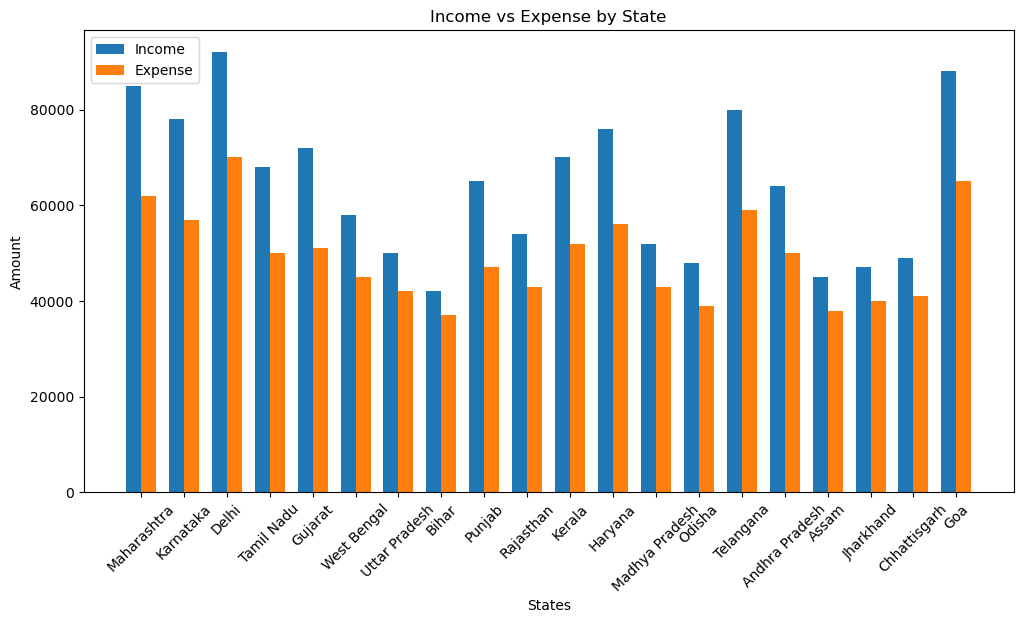

In [17]:
plt.figure(figsize=(12,6))

x = np.arange(len(df["State"]))
width = 0.35

plt.bar(
    x - width/2,
    df["Monthly_Income"],
    width,
    label="Income"
)

plt.bar(
    x + width/2,
    df["Monthly_Expense"],
    width,
    label="Expense"
)

plt.xticks(x, df["State"], rotation=45)

plt.title("Income vs Expense by State")
plt.xlabel("States")
plt.ylabel("Amount")
plt.legend()

plt.show()

C:\Users\bande\AppData\Local\Temp\ipykernel_5552\661950662.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


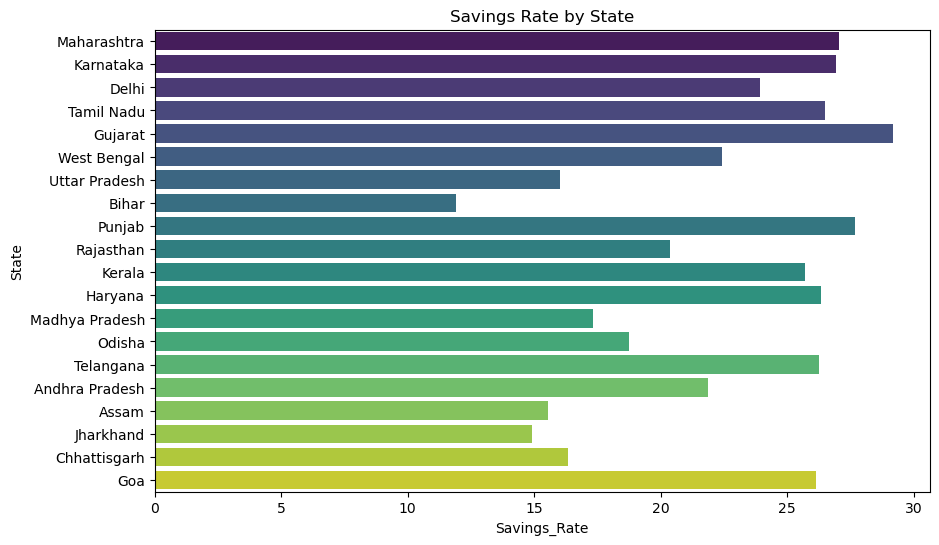

In [18]:
# Savings Rate


plt.figure(figsize=(10,6))

sns.barplot(
    x="Savings_Rate",
    y="State",
    data=df,
    palette="viridis"
)

plt.title("Savings Rate by State")
plt.show()

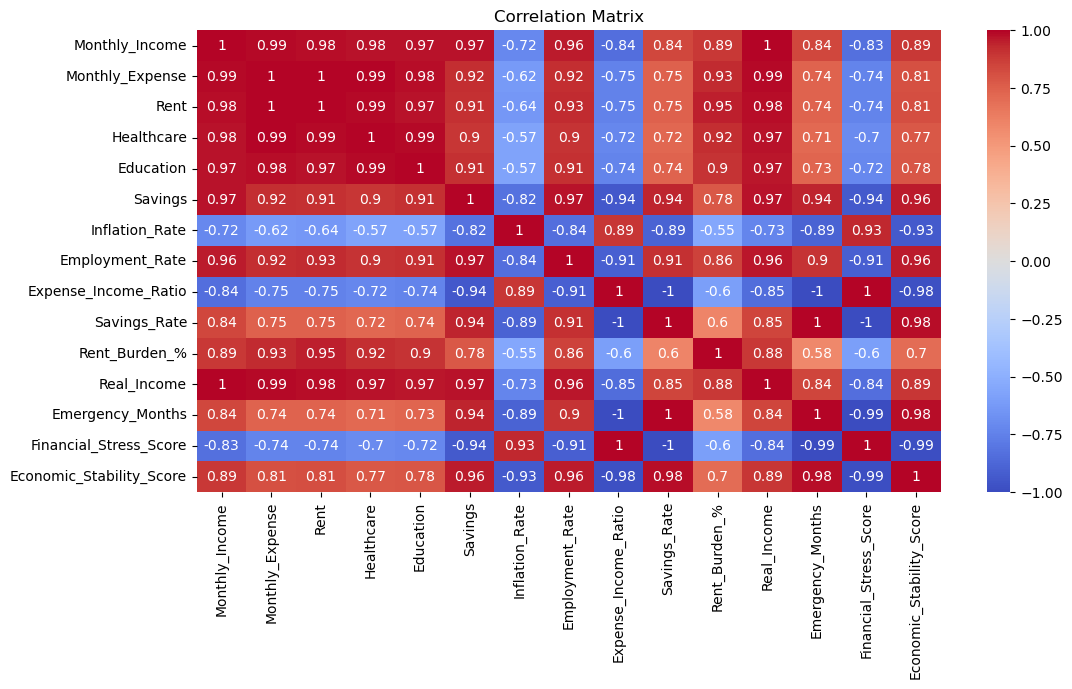

In [19]:
plt.figure(figsize=(12,6))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

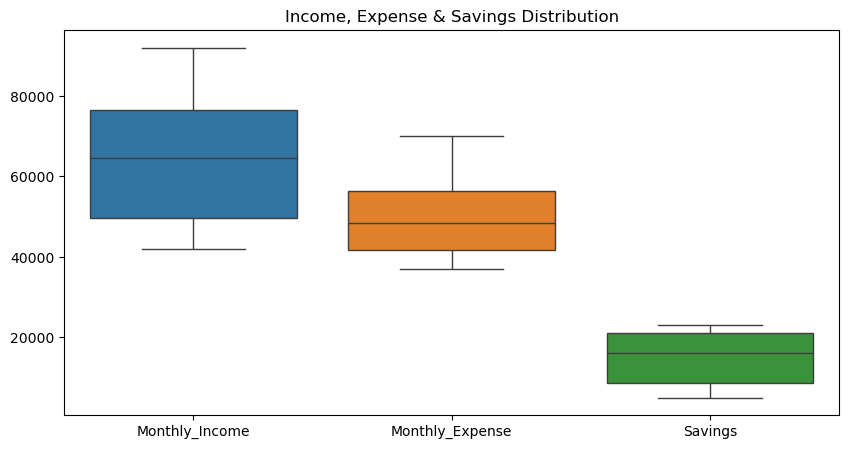

In [20]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df[[
        "Monthly_Income",
        "Monthly_Expense",
        "Savings"
    ]]
)

plt.title("Income, Expense & Savings Distribution")

plt.show()

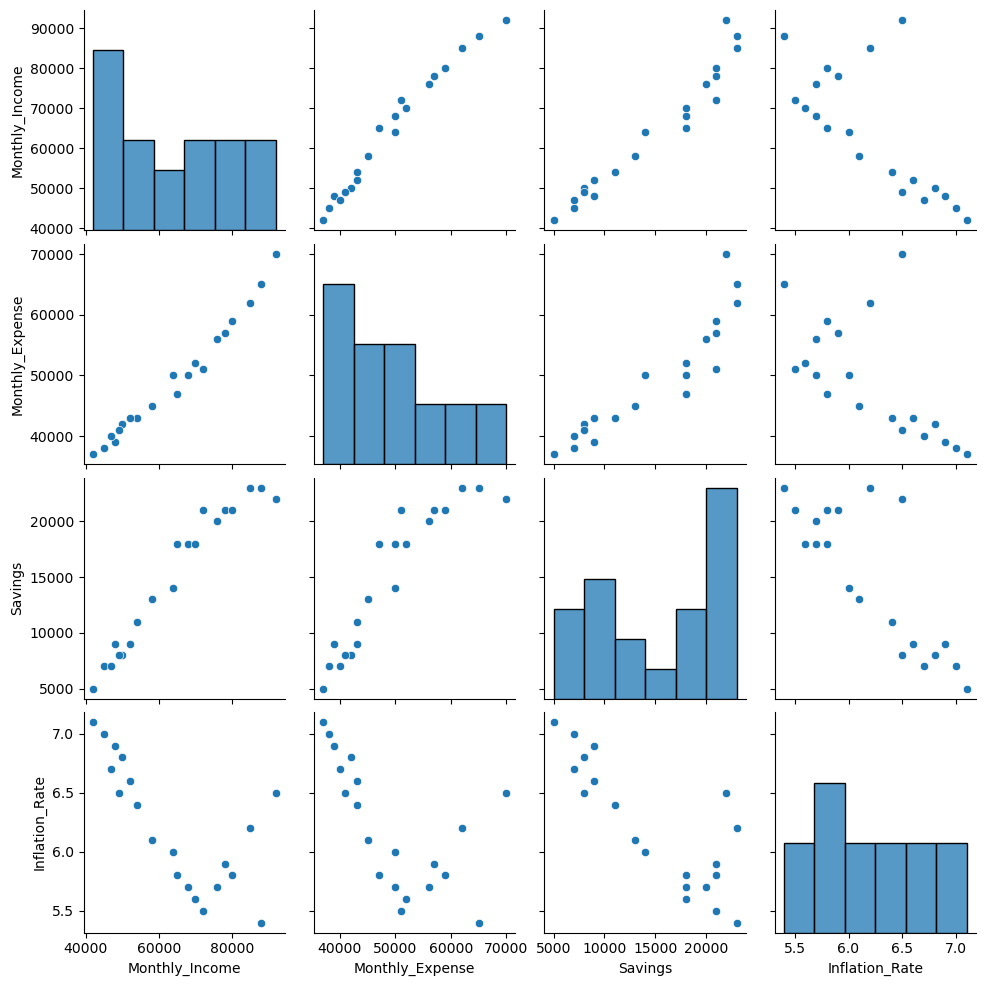

In [21]:
sns.pairplot(
    df[[
        "Monthly_Income",
        "Monthly_Expense",
        "Savings",
        "Inflation_Rate"
    ]]
)

plt.show()

In [22]:
# Business Insights
# ======================================

print("Business Insights")

print("1. Metro cities earn higher salaries but also face higher cost-of-living pressure.")

print("2. Inflation reduces effective purchasing power across all states.")

print("3. High rent burden directly affects middle-class savings.")

print("4. States with strong employment rates show better financial stability.")

print("5. Lower-income states are more vulnerable to inflation shocks.")

print("6. Savings behavior plays critical role in economic resilience.")

Business Insights
1. Metro cities earn higher salaries but also face higher cost-of-living pressure.
2. Inflation reduces effective purchasing power across all states.
3. High rent burden directly affects middle-class savings.
4. States with strong employment rates show better financial stability.
5. Lower-income states are more vulnerable to inflation shocks.
6. Savings behavior plays critical role in economic resilience.
